# KNN-Based Synthetic Salary Generation — Bank Customer Data

**Methodology:** *KNN Whole Dataset Synthetic Data Methodology* (adapted for **one column only**)

**Scope:** Synthetically generate **`estimated_salary` only**. All other columns stay **unchanged**.

| Doc step | This notebook |
|----------|----------------|
| 1–2 | Load & clean empty columns |
| 3 | Classify columns — salary = synthesis target |
| 4 | Validate input (salary profile + column summary) |
| 5–6 | Preprocess categoricals + numericals for KNN (**salary excluded** from similarity) |
| 7 | Mixed Hamming + Euclidean distance |
| 8–9 | Generate salary (interpolation / weighted mean / blend) + jitter + caps |
| 10 | Validate output (§8.1–§8.6) |
| 11 | Scorecard + export CSV |


In [1]:
# --- Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ks_2samp, skew
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.feature_selection import mutual_info_classif

sns.set_style("whitegrid")


In [2]:
# --- Settings ---
FILE_PATH = "Bank Customer Churn Prediction.csv"
OUTPUT_PATH = "bank_churn_synthetic_salary.csv"
RANDOM_STATE = 42

SALARY_COL = "estimated_salary"
TARGET_COL = "churn"
ID_COLS = ["customer_id"]

CATEGORICAL_COLS = ["country", "gender"]
KNN_NUM_COLS = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "credit_card", "active_member",
]

K_NEIGHBORS = 15
CAT_WEIGHT = 1.0
NUM_WEIGHT = 1.0
MISSING_LABEL = "Missing"
SCALER_METHOD = "standard"
SALARY_METHOD = "blend"           # interpolation | weighted_mean | blend (recommended)
BLEND_ALPHA = 0.999               # high alpha keeps salary close to original
JITTER_FRAC = 0.003               # small noise for privacy (0 = off)

TEST_SIZE = 0.2
N_COMPARE = 500


## Step 1 — Load dataset (doc §3)


In [3]:
column_handling_log = []
df_raw = pd.read_csv(FILE_PATH)
df = df_raw.replace(r"^\s*$", np.nan, regex=True)

empty_cols = [c for c in df.columns if df[c].isna().all()]
if empty_cols:
    df = df.drop(columns=empty_cols)
    for c in empty_cols:
        column_handling_log.append({"column": c, "action": "dropped", "reason": "fully empty"})

ORIGINAL_COLUMNS = list(df.columns)
print("Shape:", df.shape)
df.head()


Shape: (10000, 12)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 2 — Identify column types (doc §4)


In [4]:
column_roles = pd.DataFrame({
    "column": df.columns,
    "role": [
        "id" if c in ID_COLS else
        "synthesis_target" if c == SALARY_COL else
        "target" if c == TARGET_COL else
        "categorical_knn" if c in CATEGORICAL_COLS else
        "numerical_knn" if c in KNN_NUM_COLS else
        "unchanged"
        for c in df.columns
    ],
})
print(column_roles.to_string(index=False))
print("\nKNN features:", CATEGORICAL_COLS + KNN_NUM_COLS)
print("Synthesis target:", SALARY_COL)


          column             role
     customer_id               id
    credit_score    numerical_knn
         country  categorical_knn
          gender  categorical_knn
             age    numerical_knn
          tenure    numerical_knn
         balance    numerical_knn
 products_number    numerical_knn
     credit_card    numerical_knn
   active_member    numerical_knn
estimated_salary synthesis_target
           churn           target

KNN features: ['country', 'gender', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member']
Synthesis target: estimated_salary


## Step 3 — Validate before synthesis (doc §5)


In [5]:
s = df[SALARY_COL].dropna()
print("=== Salary profile ===")
print(f"  mean={s.mean():,.2f}  median={s.median():,.2f}  std={s.std():,.2f}")
print(f"  skew={skew(s):.3f}  P1={s.quantile(0.01):,.2f}  P99={s.quantile(0.99):,.2f}")
print(f"  missing%={100*df[SALARY_COL].isna().mean():.2f}")

val = pd.DataFrame({
    "column": df.columns,
    "missing_pct": (100 * df.isna().mean()).round(2),
    "n_unique": df.nunique().values,
})
print("\n=== All columns ===")
print(val.to_string(index=False))


=== Salary profile ===
  mean=100,090.24  median=100,193.91  std=57,510.49
  skew=0.002  P1=1,842.83  P99=198,069.73
  missing%=0.00

=== All columns ===
          column  missing_pct  n_unique
     customer_id          0.0     10000
    credit_score          0.0       460
         country          0.0         3
          gender          0.0         2
             age          0.0        70
          tenure          0.0        11
         balance          0.0      6382
 products_number          0.0         4
     credit_card          0.0         2
   active_member          0.0         2
estimated_salary          0.0      9999
           churn          0.0         2


## Step 4 — Train / test split

Fit preprocessors on **train**; neighbours always from **train pool**.


In [6]:
train_idx, test_idx = train_test_split(df.index, test_size=TEST_SIZE, random_state=RANDOM_STATE)
df_train = df.loc[train_idx].copy().reset_index(drop=True)
df_test = df.loc[test_idx].copy().reset_index(drop=True)
print(f"Train: {len(df_train)} | Test: {len(df_test)}")


Train: 8000 | Test: 2000


## Step 5 — Preprocess categoricals (doc §6.1)


In [7]:
cat_encoders = {}
for col in CATEGORICAL_COLS:
    enc = LabelEncoder()
    enc.fit(df_train[col].astype(str).fillna(MISSING_LABEL))
    cat_encoders[col] = enc

def encode_cats(frame):
    return np.column_stack([
        cat_encoders[c].transform(frame[c].astype(str).fillna(MISSING_LABEL))
        for c in CATEGORICAL_COLS
    ])

X_cat_train = encode_cats(df_train)
X_cat_test = encode_cats(df_test)
print("Categorical matrix:", X_cat_train.shape)


Categorical matrix: (8000, 2)


## Step 6 — Preprocess numericals for KNN (doc §6.2)

Salary scaled **separately** as synthesis target.


In [8]:
knn_medians = df_train[KNN_NUM_COLS].median()

def fit_scaler(method, X):
    scalers = {"standard": StandardScaler, "minmax": MinMaxScaler, "robust": RobustScaler}
    return scalers[method]().fit(X)

knn_scaler = fit_scaler(SCALER_METHOD, df_train[KNN_NUM_COLS].fillna(knn_medians).values)
X_num_train = knn_scaler.transform(df_train[KNN_NUM_COLS].fillna(knn_medians).values)
X_num_test = knn_scaler.transform(df_test[KNN_NUM_COLS].fillna(knn_medians).values)

y_train_salary = df_train[SALARY_COL].values
y_test_salary = df_test[SALARY_COL].values
salary_scaler = StandardScaler().fit(y_train_salary.reshape(-1, 1))
salary_p01, salary_p99 = np.percentile(y_train_salary, 1), np.percentile(y_train_salary, 99)
print("KNN num:", X_num_train.shape, "| salary scaler fitted")


KNN num: (8000, 7) | salary scaler fitted


## Step 7 — Mixed KNN distance (doc §6.3)

`distance = NUM_WEIGHT × euclidean(num) + CAT_WEIGHT × hamming(cat)`


In [9]:
def hamming_cat_distance(cat_a, cat_b):
    if cat_a.ndim == 1:
        cat_a = cat_a.reshape(1, -1)
    if cat_b.ndim == 1:
        cat_b = cat_b.reshape(1, -1)
    return np.mean(cat_a != cat_b, axis=1)


def find_neighbours(base_num, base_cat, X_num_pool, X_cat_pool, k):
    num_dist = np.linalg.norm(X_num_pool - base_num, axis=1)
    cat_dist = hamming_cat_distance(X_cat_pool, base_cat)
    total = NUM_WEIGHT * num_dist + CAT_WEIGHT * cat_dist
    idx = np.argpartition(total, k)[:k]
    return total[idx], idx[np.argsort(total[idx])]


## Step 8 — Generate synthetic salary (doc §7.2)

For each row: find similar customers (without using salary in distance), then:
- **interpolation** (default): scaled `base + w×(neighbour−base)`
- **weighted_mean**: distance-weighted neighbour salaries
- **blend**: `α×original + (1−α)×weighted_mean`


In [10]:
rng = np.random.default_rng(RANDOM_STATE)


def synthesize_salary(base_salary, base_num, base_cat, method):
    dists, nbrs = find_neighbours(base_num, base_cat, X_num_train, X_cat_train, K_NEIGHBORS)
    w = (1.0 / (dists + 1e-8))
    w /= w.sum()
    nbr_salaries = y_train_salary[nbrs]

    if method == "interpolation":
        base_s = salary_scaler.transform([[base_salary]])[0, 0]
        nbr_s = salary_scaler.transform(nbr_salaries.reshape(-1, 1)).flatten()
        nj, t = rng.integers(len(nbrs)), rng.random()
        synth_s = base_s + t * (nbr_s[nj] - base_s)
        return salary_scaler.inverse_transform([[synth_s]])[0, 0]

    if method == "weighted_mean":
        return float(np.dot(w, nbr_salaries))

    if method == "blend":
        return BLEND_ALPHA * base_salary + (1 - BLEND_ALPHA) * float(np.dot(w, nbr_salaries))

    raise ValueError(method)


def batch_salary(df_part, X_num, X_cat, method):
    return np.array([
        synthesize_salary(df_part[SALARY_COL].iloc[i], X_num[i], X_cat[i], method)
        for i in range(len(df_part))
    ])


jitter_std = JITTER_FRAC * np.std(y_train_salary) if JITTER_FRAC > 0 else 0.0

def apply_jitter(values):
    if jitter_std == 0:
        return values
    return values + rng.normal(0, jitter_std, size=len(values))

salary_train_syn = np.clip(apply_jitter(batch_salary(df_train, X_num_train, X_cat_train, SALARY_METHOD)), salary_p01, salary_p99)
salary_test_syn = np.clip(apply_jitter(batch_salary(df_test, X_num_test, X_cat_test, SALARY_METHOD)), salary_p01, salary_p99)

print(f"Method: {SALARY_METHOD}")
print(f"Train mean |% change|: {np.mean(100*np.abs(salary_train_syn-y_train_salary)/y_train_salary):.2f}%")
print(f"Test  mean |% change|: {np.mean(100*np.abs(salary_test_syn-y_test_salary)/y_test_salary):.2f}%")


Method: blend
Train mean |% change|: 2.76%
Test  mean |% change|: 11.17%


## Step 8b — Compare salary approaches


In [11]:
rows = []
for method in ["interpolation", "weighted_mean", "blend"]:
    syn = np.clip(batch_salary(df_test.head(N_COMPARE), X_num_test[:N_COMPARE], X_cat_test[:N_COMPARE], method), salary_p01, salary_p99)
    orig = df_test[SALARY_COL].values[:N_COMPARE]
    rows.append({
        "method": method,
        "mean_%_change": round(np.mean(100 * np.abs(syn - orig) / orig), 2),
        "corr": round(np.corrcoef(orig, syn)[0, 1], 4),
        "KS": round(ks_2samp(orig, syn).statistic, 4),
    })
print(pd.DataFrame(rows).to_string(index=False))


       method  mean_%_change   corr    KS
interpolation         168.21 0.6265 0.098
weighted_mean         365.57 0.0176 0.358
        blend           2.87 1.0000 0.010


## Step 9 — Assemble output (doc reverse-transform step)

All columns unchanged except `estimated_salary`.


In [12]:
df_out_train = df_train.copy()
df_out_test = df_test.copy()
df_out_train[SALARY_COL] = salary_train_syn
df_out_test[SALARY_COL] = salary_test_syn

orig_all = pd.concat([df_train, df_test], ignore_index=True)
syn_all = pd.concat([df_out_train, df_out_test], ignore_index=True)
syn_all["estimated_salary_actual"] = orig_all[SALARY_COL].values

syn_all[[SALARY_COL, "estimated_salary_actual", "country", "age"]].head()


,estimated_salary,estimated_salary_actual,country,age
0,179145.837675,179093.26,France,32
1,195799.414904,195978.86,Germany,42
2,86020.507337,85891.02,Spain,24
3,153242.690650,153080.40,France,27
4,39151.396735,39488.04,France,56


## Step 10 — Validation (doc §8)


§8.1 Non-salary unchanged: True
§8.3 Salary KS: 0.0101 | corr: 1.0 | mean % chg: 4.44
§8.4 Mean correlation drift: 6e-06


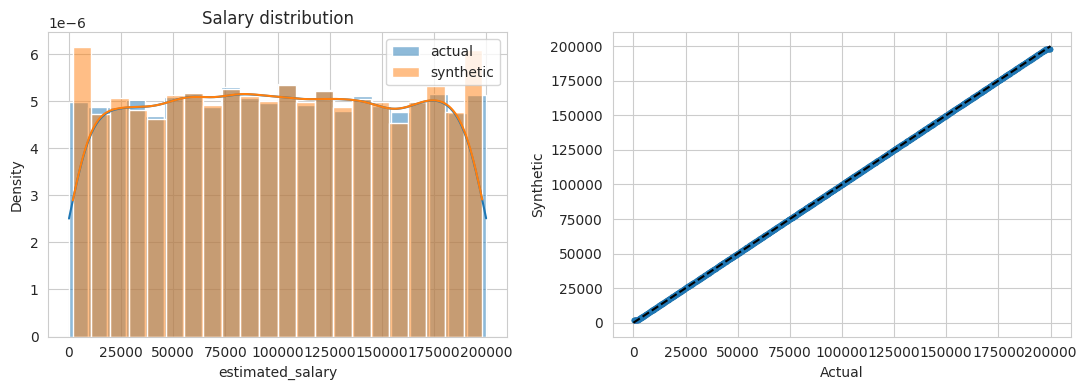

In [13]:
non_salary = [c for c in ORIGINAL_COLUMNS if c != SALARY_COL]
struct_ok = all((syn_all[c].values == orig_all[c].values).all() for c in non_salary)

act, syn = orig_all[SALARY_COL], syn_all[SALARY_COL]
ks_stat, ks_p = ks_2samp(act, syn)
mean_pct = np.mean(100 * np.abs(syn - act) / act)

print("§8.1 Non-salary unchanged:", struct_ok)
print("§8.3 Salary KS:", round(ks_stat, 4), "| corr:", round(np.corrcoef(act, syn)[0,1], 4), "| mean % chg:", round(mean_pct, 2))

corr_cols = KNN_NUM_COLS + [SALARY_COL, TARGET_COL]
triu = (orig_all[corr_cols].corr() - syn_all[corr_cols].corr()).abs().values
triu = triu[np.triu_indices_from(triu, 1)]
print("§8.4 Mean correlation drift:", round(triu.mean(), 6))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(act, kde=True, ax=ax[0], label="actual", stat="density", alpha=0.5)
sns.histplot(syn, kde=True, ax=ax[0], label="synthetic", stat="density", alpha=0.5)
ax[0].legend(); ax[0].set_title("Salary distribution")
ax[1].scatter(act, syn, alpha=0.2, s=8)
lo, hi = act.min(), act.max()
ax[1].plot([lo, hi], [lo, hi], "k--")
ax[1].set_xlabel("Actual"); ax[1].set_ylabel("Synthetic")
plt.tight_layout(); plt.show()


In [14]:
def encode_churn(frame):
    out = frame[KNN_NUM_COLS + CATEGORICAL_COLS + [SALARY_COL]].copy()
    out[KNN_NUM_COLS] = out[KNN_NUM_COLS].fillna(knn_medians)
    for c in CATEGORICAL_COLS:
        out[c] = cat_encoders[c].transform(out[c].astype(str).fillna(MISSING_LABEL))
    return out

rf_b = RandomForestClassifier(100, random_state=RANDOM_STATE).fit(encode_churn(df_train), df_train[TARGET_COL])
rf_s = RandomForestClassifier(100, random_state=RANDOM_STATE).fit(encode_churn(df_out_train), df_train[TARGET_COL])
X_te = encode_churn(df_test)
f1_b = f1_score(df_test[TARGET_COL], rf_b.predict(X_te))
f1_s = f1_score(df_test[TARGET_COL], rf_s.predict(encode_churn(df_out_test)))
print("§8.5 F1 actual salary:", round(f1_b, 4), "| synthetic salary:", round(f1_s, 4))


§8.5 F1 actual salary: 0.5778 | synthetic salary: 0.5858


## Step 11 — Scorecard & export (doc §10–§11)


In [15]:
scorecard = pd.DataFrame([
    {"area": "Structure", "metric": "non_salary_unchanged", "pass": struct_ok},
    {"area": "Salary", "metric": "corr>0.99", "pass": np.corrcoef(act, syn)[0,1] > 0.99},
    {"area": "Salary", "metric": "mean_%_change<15", "pass": mean_pct < 15},
    {"area": "Salary", "metric": "KS<0.1", "pass": ks_stat < 0.1},
    {"area": "Relationships", "metric": "corr_drift<0.02", "pass": triu.mean() < 0.02},
    {"area": "Utility", "metric": "F1>=80% of baseline", "pass": f1_s >= 0.8 * f1_b},
])
print(scorecard.to_string(index=False))
print("Overall pass:", scorecard["pass"].all())

export_df = syn_all[ORIGINAL_COLUMNS]
export_df.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved: {OUTPUT_PATH}")
export_df.head()


         area               metric  pass
    Structure non_salary_unchanged  True
       Salary            corr>0.99  True
       Salary     mean_%_change<15  True
       Salary               KS<0.1  True
Relationships      corr_drift<0.02  True
      Utility  F1>=80% of baseline  True
Overall pass: True

Saved: bank_churn_synthetic_salary.csv


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15601116,686,France,Male,32,6,0.00,2,1,1,179145.837675,0
1,15766374,632,Germany,Male,42,4,119624.60,2,1,1,195799.414904,0
2,15716994,559,Spain,Male,24,3,114739.92,1,1,0,86020.507337,1
3,15730759,561,France,Female,27,9,135637.00,1,1,0,153242.690650,1
4,15797900,517,France,Male,56,9,142147.32,1,0,0,39151.396735,1
